# 16_prepare_mel_nv_synthetic_cue_csv

Prepare two controlled MEL vs NV datasets for the synthetic cue experiment:

1. **Clean MEL vs NV**: original images, original lesion masks.
2. **Cue MEL vs NV**: MEL images receive a synthetic green cue inside the lesion; NV images stay unchanged.

The notebook also saves a binary cue mask per modified MEL image and visualizes examples for sanity checking.

In [1]:
from pathlib import Path
import json
import shutil

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

REPO_ROOT = Path("..").resolve()
HAM_ROOT = REPO_ROOT / "data" / "HAM10000"

HAM_CSV = HAM_ROOT / "HAM10000.csv"
SEG_OVERLAP_CSV = HAM_ROOT / "ham_segmentation_overlap.csv"

# All generated files are kept nested and traceable here.
SEED = 42

# Variant name controls where files are saved.
# Keep fixed and random in separate nested folders.
FIXED_EXPERIMENT_NAME = f"mel_nv_fixed_center_seed{SEED}"
RANDOM_EXPERIMENT_NAME = f"mel_nv_random_location_seed{SEED}"

SYN_ROOT_FIXED = HAM_ROOT / "synthetic_cue" / FIXED_EXPERIMENT_NAME
SYN_ROOT_RANDOM = HAM_ROOT / "synthetic_cue" / RANDOM_EXPERIMENT_NAME

def make_dirs(syn_root: Path):
    image_out_dir = syn_root / "images"
    cue_mask_out_dir = syn_root / "cue_masks"
    csv_out_dir = syn_root / "csv"
    for p in [image_out_dir, cue_mask_out_dir, csv_out_dir]:
        p.mkdir(parents=True, exist_ok=True)
    return image_out_dir, cue_mask_out_dir, csv_out_dir

IMAGE_OUT_DIR_FIXED, CUE_MASK_OUT_DIR_FIXED, CSV_OUT_DIR_FIXED = make_dirs(SYN_ROOT_FIXED)
IMAGE_OUT_DIR_RANDOM, CUE_MASK_OUT_DIR_RANDOM, CSV_OUT_DIR_RANDOM = make_dirs(SYN_ROOT_RANDOM)

CLEAN_OUT_CSV_FIXED = CSV_OUT_DIR_FIXED / "ham_mel_nv_clean.csv"
CUE_OUT_CSV_FIXED = CSV_OUT_DIR_FIXED / f"ham_mel_nv_cue_on_mel_fixed_center_seed{SEED}.csv"

CLEAN_OUT_CSV_RANDOM = CSV_OUT_DIR_RANDOM / "ham_mel_nv_clean.csv"
CUE_OUT_CSV_RANDOM = CSV_OUT_DIR_RANDOM / f"ham_mel_nv_cue_on_mel_random_location_seed{SEED}.csv"

print("Fixed root:", SYN_ROOT_FIXED)
print("Random root:", SYN_ROOT_RANDOM)

Fixed root: /Users/choekyelnyungmartsang/Developer/master-thesis/data/HAM10000/synthetic_cue/mel_nv_fixed_center_seed42
Random root: /Users/choekyelnyungmartsang/Developer/master-thesis/data/HAM10000/synthetic_cue/mel_nv_random_location_seed42


## 1. Configuration

The first version uses a fixed, deterministic cue near the lesion center. The cue size is scaled relative to lesion area, then clamped to avoid being too small or too large.

In [2]:
# Synthetic cue settings
TARGET_CUE_AREA_FRAC = 0.6 # 0.18
MIN_CUE_SIDE = 80 # 24
MAX_CUE_SIDE = 160 # 80

CUE_CLASS = "MEL"
NEGATIVE_CLASS = "NV"

# Main first control setting
CUE_COLOR_RGB = (0, 255, 0)   # green
CUE_SHAPE = "square"          # options: "square", "circle", "triangle"

# Later you can change these:
# CUE_COLOR_RGB = (255, 0, 0)      # red
# CUE_COLOR_RGB = (0, 0, 255)      # blue
# CUE_COLOR_RGB = (0, 255, 0)      # green
# CUE_SHAPE = "circle"
# CUE_SHAPE = "triangle"
# CUE_SHAPE = "square"

CLASS2_TO_IDX = {"MEL": 0, "NV": 1}
IDX_TO_CLASS2 = {v: k for k, v in CLASS2_TO_IDX.items()}

rng = np.random.default_rng(SEED)

print({
    "seed": SEED,
    "target_cue_area_frac": TARGET_CUE_AREA_FRAC,
    "min_cue_side": MIN_CUE_SIDE,
    "max_cue_side": MAX_CUE_SIDE,
    "cue_color_rgb": CUE_COLOR_RGB,
    "cue_shape": CUE_SHAPE,
    "cue_class": CUE_CLASS,
    "class2_to_idx": CLASS2_TO_IDX,
})

{'seed': 42, 'target_cue_area_frac': 0.6, 'min_cue_side': 80, 'max_cue_side': 160, 'cue_color_rgb': (0, 255, 0), 'cue_shape': 'square', 'cue_class': 'MEL', 'class2_to_idx': {'MEL': 0, 'NV': 1}}


## 2. Load and merge HAM10000 metadata with segmentation mask paths

In [3]:
ham_df = pd.read_csv(HAM_CSV)
seg_df = pd.read_csv(SEG_OVERLAP_CSV)

print("HAM10000 shape:", ham_df.shape)
print("Seg overlap shape:", seg_df.shape)
print("HAM columns:", ham_df.columns.tolist())
print("Seg columns:", seg_df.columns.tolist())

# Normalize join keys.
ham_df["image_id"] = ham_df["image_id"].astype(str)
seg_df["image_id"] = seg_df["image_id"].astype(str)

# Keep only useful segmentation columns.
seg_keep = [c for c in ["image_id", "image_rel_path", "mask_rel_path", "mask_found"] if c in seg_df.columns]

merged = ham_df.merge(
    seg_df[seg_keep],
    on="image_id",
    how="left",
    suffixes=("", "_seg"),
)

# Prefer segmentation-overlap paths if they exist.
if "image_rel_path_seg" in merged.columns:
    base_image_rel = (
        merged["image_rel_path"]
        if "image_rel_path" in merged.columns
        else pd.Series(index=merged.index, dtype=object)
    )
    merged["image_rel_path"] = merged["image_rel_path_seg"].combine_first(base_image_rel)

if "mask_rel_path_seg" in merged.columns:
    base_mask_rel = (
        merged["mask_rel_path"]
        if "mask_rel_path" in merged.columns
        else pd.Series(index=merged.index, dtype=object)
    )
    merged["mask_rel_path"] = merged["mask_rel_path_seg"].combine_first(base_mask_rel)

# Derive image_rel_path if still missing.
if "image_rel_path" not in merged.columns or merged["image_rel_path"].isna().all():
    merged["image_rel_path"] = "images/" + merged["image"].astype(str)

if "mask_found" not in merged.columns:
    raise ValueError("mask_found column missing after merge. Check SEG_OVERLAP_CSV columns.")

# Standard class labels.
merged["gt_label"] = merged["dx"].astype(str).str.upper()
merged["dx_norm"] = merged["dx"].astype(str).str.lower()

# Keep MEL/NV with available masks.
mel_nv_df = merged[
    merged["gt_label"].isin(["MEL", "NV"])
    & merged["mask_found"].fillna(0).astype(int).eq(1)
].copy()


def make_balanced_by_split(
    df,
    class_col="gt_label",
    split_col="split",
    classes=("MEL", "NV"),
    seed=42,
):
    balanced_parts = []

    for split_name, split_df in df.groupby(split_col):
        class_counts = split_df[class_col].value_counts()

        if not all(cls in class_counts for cls in classes):
            print(f"[warn] split={split_name}: missing one class, skipping")
            continue

        n_min = min(class_counts[cls] for cls in classes)

        for cls in classes:
            cls_df = split_df[split_df[class_col] == cls].copy()
            sampled = cls_df.sample(n=n_min, random_state=seed)
            balanced_parts.append(sampled)

        print(f"split={split_name}: selected {n_min} {classes[0]} and {n_min} {classes[1]}")

    if len(balanced_parts) == 0:
        raise ValueError("No balanced splits were created.")

    balanced_df = pd.concat(balanced_parts, axis=0).copy()
    balanced_df = balanced_df.sort_values([split_col, class_col, "image_id"]).reset_index(drop=True)

    return balanced_df


CLASS2_TO_IDX = {"MEL": 0, "NV": 1}

mel_nv = make_balanced_by_split(
    mel_nv_df,
    class_col="gt_label",
    split_col="split",
    classes=("MEL", "NV"),
    seed=42,
)

mel_nv["label_2class"] = mel_nv["gt_label"].map(CLASS2_TO_IDX).astype(int)
mel_nv["binary_label"] = mel_nv["label_2class"]
mel_nv["cue_applied"] = False
mel_nv["cue_mask_rel_path"] = ""
mel_nv["cue_center_x"] = np.nan
mel_nv["cue_center_y"] = np.nan
mel_nv["cue_side"] = np.nan
mel_nv["cue_area_px"] = np.nan
mel_nv["lesion_area_px"] = np.nan
mel_nv["cue_area_frac_of_lesion"] = np.nan
mel_nv["cue_color_rgb"] = ""
mel_nv["cue_mode"] = "clean"

print("Balanced MEL/NV with masks:", mel_nv.shape)
display(mel_nv.groupby(["split", "gt_label"]).size().unstack(fill_value=0))
display(mel_nv.head())

HAM10000 shape: (10015, 13)
Seg overlap shape: (10015, 7)
HAM columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization', 'dataset', 'split', 'label', 'image', 'binary_label', 'age_group']
Seg columns: ['image_id', 'label', 'dx', 'split', 'image_rel_path', 'mask_rel_path', 'mask_found']
split=test: selected 70 MEL and 70 NV
split=train: selected 1021 MEL and 1021 NV
split=val: selected 22 MEL and 22 NV
Balanced MEL/NV with masks: (2226, 29)


gt_label,MEL,NV
split,,
test,70,70
train,1021,1021
val,22,22


,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,split,label,image,binary_label,age_group,image_rel_path,mask_rel_path,mask_found,gt_label,dx_norm,label_2class,cue_applied,cue_mask_rel_path,cue_center_x,cue_center_y,cue_side,cue_area_px,lesion_area_px,cue_area_frac_of_lesion,cue_color_rgb,cue_mode
0,HAM_0005846,ISIC_0024459,mel,histo,80.0,male,back,vienna_dias,test,4,ISIC_0024459.jpg,0,old,images/ISIC_0024459.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,1,MEL,mel,0,False,,NaN,NaN,NaN,NaN,NaN,NaN,,clean
1,HAM_0006699,ISIC_0024571,mel,histo,65.0,male,face,rosendahl,test,4,ISIC_0024571.jpg,0,old,images/ISIC_0024571.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,1,MEL,mel,0,False,,NaN,NaN,NaN,NaN,NaN,NaN,,clean
2,HAM_0000210,ISIC_0024624,mel,histo,75.0,female,face,vidir_modern,test,4,ISIC_0024624.jpg,0,old,images/ISIC_0024624.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,1,MEL,mel,0,False,,NaN,NaN,NaN,NaN,NaN,NaN,,clean
3,HAM_0005467,ISIC_0024640,mel,histo,55.0,female,back,vienna_dias,test,4,ISIC_0024640.jpg,0,old,images/ISIC_0024640.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,1,MEL,mel,0,False,,NaN,NaN,NaN,NaN,NaN,NaN,,clean
4,HAM_0007272,ISIC_0024756,mel,histo,60.0,male,lower extremity,rosendahl,test,4,ISIC_0024756.jpg,0,old,images/ISIC_0024756.jpg,../HAM10000_segmentations_lesion_tschandl/ISIC...,1,MEL,mel,0,False,,NaN,NaN,NaN,NaN,NaN,NaN,,clean


## 3. Helper functions for image, mask, cue placement, and saving

In [4]:
def resolve_rel_path(root: Path, rel_or_abs: str) -> Path:
    """Resolve paths like images/xxx.jpg or ../HAM10000_segmentations... robustly."""
    p = Path(str(rel_or_abs))
    if p.is_absolute():
        return p
    return (root / p).resolve()


def load_rgb_image(row: pd.Series) -> Image.Image:
    img_path = resolve_rel_path(HAM_ROOT, row["image_rel_path"])
    if not img_path.exists():
        # fallback to HAM image column
        img_path = HAM_ROOT / "images" / str(row["image"])
    if not img_path.exists():
        raise FileNotFoundError(f"Image not found for {row['image_id']}: {img_path}")
    return Image.open(img_path).convert("RGB")


def load_lesion_mask(row: pd.Series) -> np.ndarray:
    mask_path = resolve_rel_path(HAM_ROOT, row["mask_rel_path"])
    if not mask_path.exists():
        raise FileNotFoundError(f"Mask not found for {row['image_id']}: {mask_path}")
    mask = Image.open(mask_path).convert("L")
    mask_np = np.array(mask)
    return (mask_np > 0).astype(np.uint8)


def center_inside_lesion(mask_bin: np.ndarray) -> tuple[int, int, float]:
    """
    Deterministic lesion-center point.
    Uses distance transform so the cue is placed in a central valid lesion region.
    Returns x, y, max_distance_to_boundary.
    """
    if mask_bin.sum() == 0:
        h, w = mask_bin.shape
        return w // 2, h // 2, 0.0

    dist = cv2.distanceTransform(mask_bin.astype(np.uint8), cv2.DIST_L2, 5)
    y, x = np.unravel_index(np.argmax(dist), dist.shape)
    return int(x), int(y), float(dist[y, x])


def choose_cue_side(mask_bin: np.ndarray, center_x: int, center_y: int) -> int:
    lesion_area = int(mask_bin.sum())
    side = int(round(np.sqrt(max(1, lesion_area) * TARGET_CUE_AREA_FRAC)))
    side = int(np.clip(side, MIN_CUE_SIDE, MAX_CUE_SIDE))

    # Shrink if the selected center is in a narrow lesion region.
    _, _, max_dist = center_inside_lesion(mask_bin)
    max_side_by_dist = max(3, int(2 * max_dist * 0.90))
    side = min(side, max_side_by_dist)
    side = max(3, side)
    return int(side)

def valid_random_center_inside_lesion(
    mask_bin: np.ndarray,
    side: int,
    rng: np.random.Generator,
    max_tries: int = 200,
) -> tuple[int, int]:
    """
    Pick a random center where the cue mostly fits inside the lesion.
    Falls back to distance-transform center if no good random point is found.
    """
    h, w = mask_bin.shape
    ys, xs = np.where(mask_bin > 0)

    if len(xs) == 0:
        return w // 2, h // 2

    min_required_fraction = 0.6
    half = max(1, side // 2)

    for _ in range(max_tries):
        idx = rng.integers(0, len(xs))
        cx = int(xs[idx])
        cy = int(ys[idx])

        x0 = max(0, cx - half)
        x1 = min(w, cx + half)
        y0 = max(0, cy - half)
        y1 = min(h, cy + half)

        patch = mask_bin[y0:y1, x0:x1]
        if patch.size == 0:
            continue

        if patch.mean() >= min_required_fraction:
            return cx, cy

    cx, cy, _ = center_inside_lesion(mask_bin)
    return cx, cy


def make_cue_mask(
    mask_bin: np.ndarray,
    center_x: int,
    center_y: int,
    side: int,
    shape: str = "square",
) -> np.ndarray:
    """
    Create a binary cue mask and force it to stay inside the lesion.
    Supported shapes: square, circle, triangle.
    """
    h, w = mask_bin.shape
    cue = np.zeros((h, w), dtype=np.uint8)

    half = side // 2
    x0 = max(0, center_x - half)
    x1 = min(w, center_x + half)
    y0 = max(0, center_y - half)
    y1 = min(h, center_y + half)

    if shape == "square":
        cue[y0:y1, x0:x1] = 1

    elif shape == "circle":
        radius = max(2, side // 2)
        cv2.circle(cue, (int(center_x), int(center_y)), radius, 1, thickness=-1)

    elif shape == "triangle":
        pts = np.array([
            [center_x, center_y - half],
            [center_x - half, center_y + half],
            [center_x + half, center_y + half],
        ], dtype=np.int32)
        cv2.fillPoly(cue, [pts], 1)

    else:
        raise ValueError(f"Unknown cue shape: {shape}. Use square, circle, or triangle.")

    cue = cue * mask_bin.astype(np.uint8)

    # Fallback if too little remains after restricting to lesion.
    if cue.sum() < max(4, 0.20 * side * side):
        cue = np.zeros((h, w), dtype=np.uint8)
        radius = max(2, side // 2)
        cv2.circle(cue, (int(center_x), int(center_y)), radius, 1, thickness=-1)
        cue = cue * mask_bin.astype(np.uint8)

    return cue.astype(np.uint8)


def apply_cue_to_image_with_color(
    img: Image.Image,
    cue_mask: np.ndarray,
    color_rgb: tuple[int, int, int],
) -> Image.Image:
    arr = np.array(img).copy()
    cue_bool = cue_mask.astype(bool)
    arr[cue_bool] = np.array(color_rgb, dtype=np.uint8)
    return Image.fromarray(arr)



def save_cue_mask(cue_mask: np.ndarray, out_path: Path) -> None:
    out_path.parent.mkdir(parents=True, exist_ok=True)
    Image.fromarray((cue_mask.astype(np.uint8) * 255)).save(out_path)


def rel_to_ham_root(path: Path) -> str:
    return str(path.resolve().relative_to(HAM_ROOT.resolve()))


def create_cued_mel_row(
    row: pd.Series,
    image_out_dir: Path,
    cue_mask_out_dir: Path,
    placement: str = "fixed_center",
    shape: str = "square",
    color_rgb: tuple[int, int, int] = (0, 255, 0),
    rng: np.random.Generator | None = None,
) -> pd.Series:
    """
    Create one cued MEL row.

    placement:
      - fixed_center: distance-transform lesion center
      - random_inside_lesion: random valid location inside lesion

    shape:
      - square
      - circle
      - triangle
    """
    row = row.copy()
    img = load_rgb_image(row)
    mask_bin = load_lesion_mask(row)

    if mask_bin.shape[:2] != (img.height, img.width):
        mask_bin = cv2.resize(mask_bin, (img.width, img.height), interpolation=cv2.INTER_NEAREST)
        mask_bin = (mask_bin > 0).astype(np.uint8)

    # First use center only to estimate a reasonable side.
    center_cx, center_cy, _ = center_inside_lesion(mask_bin)
    side = choose_cue_side(mask_bin, center_cx, center_cy)

    if placement == "fixed_center":
        cx, cy = center_cx, center_cy
    elif placement == "random_inside_lesion":
        if rng is None:
            rng = np.random.default_rng(SEED)
        cx, cy = valid_random_center_inside_lesion(mask_bin, side=side, rng=rng)
    else:
        raise ValueError(f"Unknown placement: {placement}")

    cue_mask = make_cue_mask(
        mask_bin=mask_bin,
        center_x=cx,
        center_y=cy,
        side=side,
        shape=shape,
    )

    cued_img = apply_cue_to_image_with_color(img, cue_mask, color_rgb=color_rgb)

    image_id = str(row["image_id"])
    image_out_path = image_out_dir / f"{image_id}.jpg"
    cue_mask_out_path = cue_mask_out_dir / f"{image_id}_cue_mask.png"

    cued_img.save(image_out_path, quality=95)
    save_cue_mask(cue_mask, cue_mask_out_path)

    lesion_area = int(mask_bin.sum())
    cue_area = int(cue_mask.sum())

    row["image_rel_path"] = rel_to_ham_root(image_out_path)
    row["cue_applied"] = True
    row["cue_mask_rel_path"] = rel_to_ham_root(cue_mask_out_path)
    row["cue_center_x"] = cx
    row["cue_center_y"] = cy
    row["cue_side"] = side
    row["cue_area_px"] = cue_area
    row["lesion_area_px"] = lesion_area
    row["cue_area_frac_of_lesion"] = cue_area / max(1, lesion_area)
    row["cue_color_rgb"] = str(color_rgb)
    row["cue_shape"] = shape
    row["cue_placement"] = placement
    row["cue_mode"] = f"mel_{placement}_{color_rgb}_{shape}_inside_lesion"

    return row


def create_clean_and_cued_csvs(
    base_df: pd.DataFrame,
    clean_out_csv: Path,
    cue_out_csv: Path,
    image_out_dir: Path,
    cue_mask_out_dir: Path,
    placement: str,
    shape: str,
    color_rgb: tuple[int, int, int],
    seed: int,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    rng_local = np.random.default_rng(seed)

    clean_df = base_df.copy()
    clean_df["cue_mode"] = "clean"
    clean_df["cue_shape"] = ""
    clean_df["cue_placement"] = ""

    cued_rows = []

    for _, row in base_df.iterrows():
        if row["gt_label"] == CUE_CLASS:
            cued_rows.append(
                create_cued_mel_row(
                    row=row,
                    image_out_dir=image_out_dir,
                    cue_mask_out_dir=cue_mask_out_dir,
                    placement=placement,
                    shape=shape,
                    color_rgb=color_rgb,
                    rng=rng_local,
                )
            )
        else:
            r = row.copy()
            r["cue_applied"] = False
            r["cue_mode"] = "no_cue_negative_class"
            r["cue_shape"] = ""
            r["cue_placement"] = ""
            cued_rows.append(r)

    cue_df = pd.DataFrame(cued_rows)

    front_cols = [
        "lesion_id", "image_id", "image", "dx", "gt_label", "label", "label_2class", "binary_label",
        "split", "image_rel_path", "mask_rel_path", "mask_found",
        "cue_applied", "cue_mask_rel_path", "cue_center_x", "cue_center_y", "cue_side",
        "cue_area_px", "lesion_area_px", "cue_area_frac_of_lesion",
        "cue_color_rgb", "cue_shape", "cue_placement", "cue_mode",
    ]

    front_cols = [c for c in front_cols if c in cue_df.columns]
    remaining_cols = [c for c in cue_df.columns if c not in front_cols]

    clean_df = clean_df[front_cols + remaining_cols].copy()
    cue_df = cue_df[front_cols + remaining_cols].copy()

    clean_out_csv.parent.mkdir(parents=True, exist_ok=True)
    cue_out_csv.parent.mkdir(parents=True, exist_ok=True)

    clean_df.to_csv(clean_out_csv, index=False)
    cue_df.to_csv(cue_out_csv, index=False)

    print("Saved clean CSV:", clean_out_csv)
    print("Saved cue CSV:", cue_out_csv)
    print("Clean rows:", len(clean_df))
    print("Cue rows:", len(cue_df))

    print("\nClean split/class counts:")
    display(clean_df.groupby(["split", "gt_label"]).size().unstack(fill_value=0))

    print("\nCue split/class counts:")
    display(cue_df.groupby(["split", "gt_label"]).size().unstack(fill_value=0))

    print("\nCue applied counts:")
    display(cue_df["cue_applied"].value_counts(dropna=False))

    return clean_df, cue_df

## 4. Create clean CSV and cued CSV

In [5]:
# Version 1: fixed center green square
clean_df_fixed, cue_df_fixed = create_clean_and_cued_csvs(
    base_df=mel_nv,
    clean_out_csv=CLEAN_OUT_CSV_FIXED,
    cue_out_csv=CUE_OUT_CSV_FIXED,
    image_out_dir=IMAGE_OUT_DIR_FIXED,
    cue_mask_out_dir=CUE_MASK_OUT_DIR_FIXED,
    placement="fixed_center",
    shape=CUE_SHAPE,
    color_rgb=CUE_COLOR_RGB,
    seed=SEED,
)

# Version 2: random location inside lesion, same green square
clean_df_random, cue_df_random = create_clean_and_cued_csvs(
    base_df=mel_nv,
    clean_out_csv=CLEAN_OUT_CSV_RANDOM,
    cue_out_csv=CUE_OUT_CSV_RANDOM,
    image_out_dir=IMAGE_OUT_DIR_RANDOM,
    cue_mask_out_dir=CUE_MASK_OUT_DIR_RANDOM,
    placement="random_inside_lesion",
    shape=CUE_SHAPE,
    color_rgb=CUE_COLOR_RGB,
    seed=SEED,
)

Saved clean CSV: /Users/choekyelnyungmartsang/Developer/master-thesis/data/HAM10000/synthetic_cue/mel_nv_fixed_center_seed42/csv/ham_mel_nv_clean.csv
Saved cue CSV: /Users/choekyelnyungmartsang/Developer/master-thesis/data/HAM10000/synthetic_cue/mel_nv_fixed_center_seed42/csv/ham_mel_nv_cue_on_mel_fixed_center_seed42.csv
Clean rows: 2226
Cue rows: 2226

Clean split/class counts:


gt_label,MEL,NV
split,,
test,70,70
train,1021,1021
val,22,22



Cue split/class counts:


gt_label,MEL,NV
split,,
test,70,70
train,1021,1021
val,22,22



Cue applied counts:


...

gt_label,MEL,NV
split,,
test,70,70
train,1021,1021
val,22,22



Cue split/class counts:


gt_label,MEL,NV
split,,
test,70,70
train,1021,1021
val,22,22



Cue applied counts:


cue_applied
True     1113
False    1113
Name: count, dtype: int64

## 5. Sanity checks: cue size ratio and paths

In [6]:
def summarize_cue_df(cue_df: pd.DataFrame, name: str):
    mel_cued = cue_df[cue_df["cue_applied"] == True].copy()

    print("\n" + "=" * 100)
    print(name)
    print("=" * 100)

    print("Cue ratio summary over MEL images:")
    display(mel_cued["cue_area_frac_of_lesion"].describe())

    print("Cue side summary:")
    display(mel_cued["cue_side"].describe())

    print("Cue placement counts:")
    display(mel_cued["cue_placement"].value_counts(dropna=False))

    print("Cue shape counts:")
    display(mel_cued["cue_shape"].value_counts(dropna=False))

    def exists_from_ham_root(rel_path):
        if pd.isna(rel_path) or str(rel_path) == "":
            return False
        return resolve_rel_path(HAM_ROOT, rel_path).exists()

    mel_cued["synthetic_image_exists"] = mel_cued["image_rel_path"].apply(exists_from_ham_root)
    mel_cued["cue_mask_exists"] = mel_cued["cue_mask_rel_path"].apply(exists_from_ham_root)

    print("Generated file existence:")
    display(
        mel_cued[
            [
                "image_id",
                "image_rel_path",
                "cue_mask_rel_path",
                "synthetic_image_exists",
                "cue_mask_exists",
                "cue_area_frac_of_lesion",
                "cue_shape",
                "cue_placement",
            ]
        ].head(10)
    )

    assert mel_cued["synthetic_image_exists"].all(), f"{name}: Some synthetic images are missing."
    assert mel_cued["cue_mask_exists"].all(), f"{name}: Some cue masks are missing."

    return mel_cued


mel_cued_fixed = summarize_cue_df(cue_df_fixed, "Fixed center green square")
mel_cued_random = summarize_cue_df(cue_df_random, "Random location green square")


Fixed center green square
Cue ratio summary over MEL images:


count    1113.000000
mean        0.355354
std         0.171802
min         0.023704
25%         0.205314
50%         0.312031
75%         0.528919
max         0.835213
Name: cue_area_frac_of_lesion, dtype: float64

Cue side summary:


count    1113.000000
mean      148.889488
std        23.970257
min        34.000000
25%       158.000000
50%       160.000000
75%       160.000000
max       160.000000
Name: cue_side, dtype: float64

Cue placement counts:


...

cue_placement
random_inside_lesion    1113
Name: count, dtype: int64

Cue shape counts:


cue_shape
square    1113
Name: count, dtype: int64

Generated file existence:


,image_id,image_rel_path,cue_mask_rel_path,synthetic_image_exists,cue_mask_exists,cue_area_frac_of_lesion,cue_shape,cue_placement
0,ISIC_0024459,synthetic_cue/mel_nv_random_location_seed42/im...,synthetic_cue/mel_nv_random_location_seed42/cu...,True,True,0.107425,square,random_inside_lesion
1,ISIC_0024571,synthetic_cue/mel_nv_random_location_seed42/im...,synthetic_cue/mel_nv_random_location_seed42/cu...,True,True,0.150652,square,random_inside_lesion
2,ISIC_0024624,synthetic_cue/mel_nv_random_location_seed42/im...,synthetic_cue/mel_nv_random_location_seed42/cu...,True,True,0.346443,square,random_inside_lesion
3,ISIC_0024640,synthetic_cue/mel_nv_random_location_seed42/im...,synthetic_cue/mel_nv_random_location_seed42/cu...,True,True,0.159730,square,random_inside_lesion
4,ISIC_0024756,synthetic_cue/mel_nv_random_location_seed42/im...,synthetic_cue/mel_nv_random_location_seed42/cu...,True,True,0.419618,square,random_inside_lesion
5,ISIC_0024886,synthetic_cue/mel_nv_random_location_seed42/im...,synthetic_cue/mel_nv_random_location_seed42/cu...,True,True,0.294097,square,random_inside_lesion
6,ISIC_0024967,synthetic_cue/mel_nv_random_location_seed42/im...,synthetic_cue/mel_nv_random_location_seed42/cu...,True,True,0.347670,square,random_inside_lesion
7,ISIC_0025105,synthetic_cue/mel_nv_random_location_seed42/im...,synthetic_cue/mel_nv_random_location_seed42/cu...,True,True,0.143620,square,random_inside_lesion
8,ISIC_0025132,synthetic_cue/mel_nv_random_location_seed42/im...,synthetic_cue/mel_nv_random_location_seed42/cu...,True,True,0.364341,square,random_inside_lesion
9,ISIC_0025234,synthetic_cue/mel_nv_random_location_seed42/im...,synthetic_cue/mel_nv_random_location_seed42/cu...,True,True,0.133263,square,random_inside_lesion


## 6. Visualize cue examples

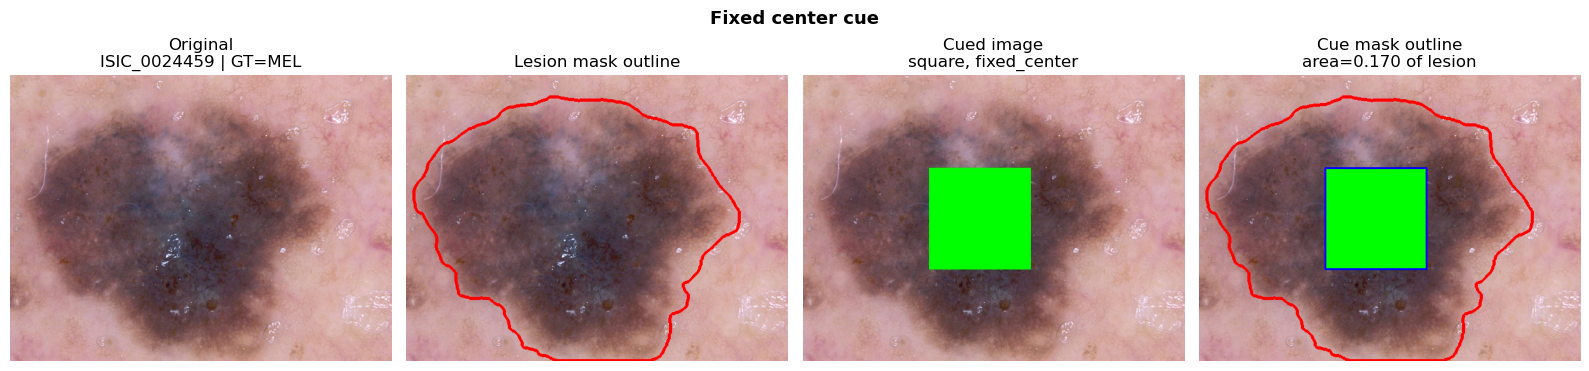

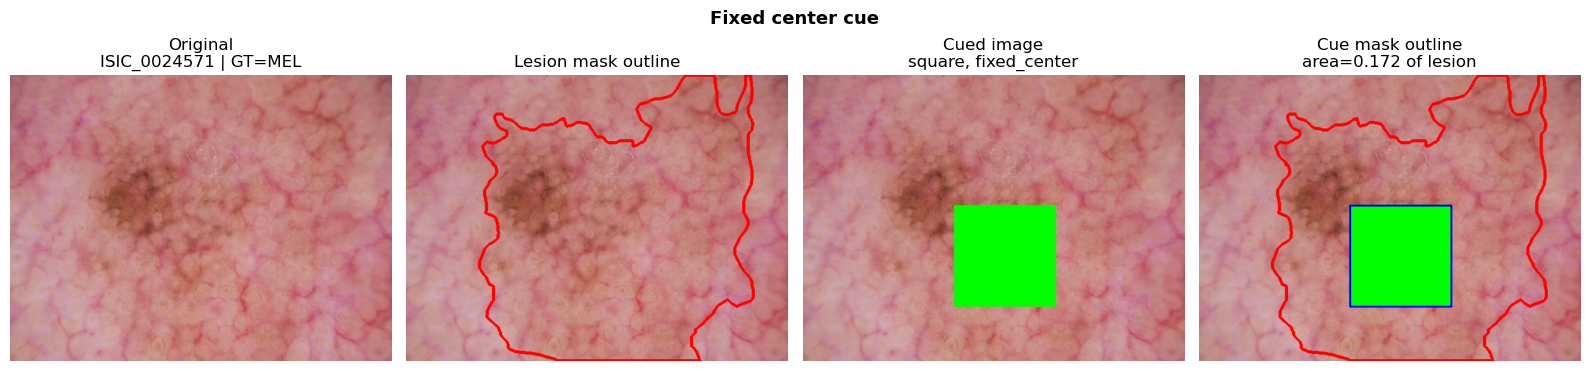

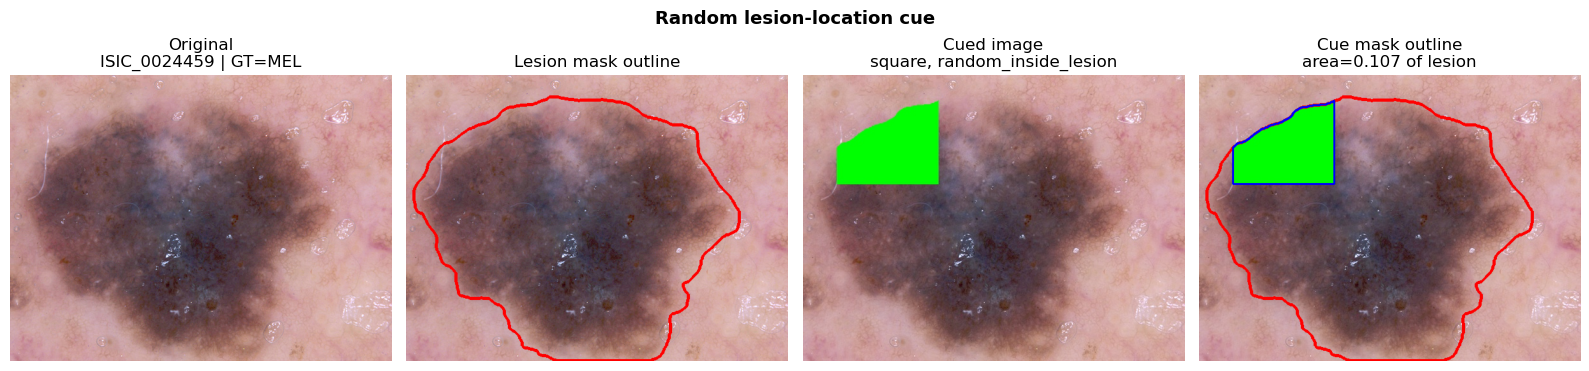

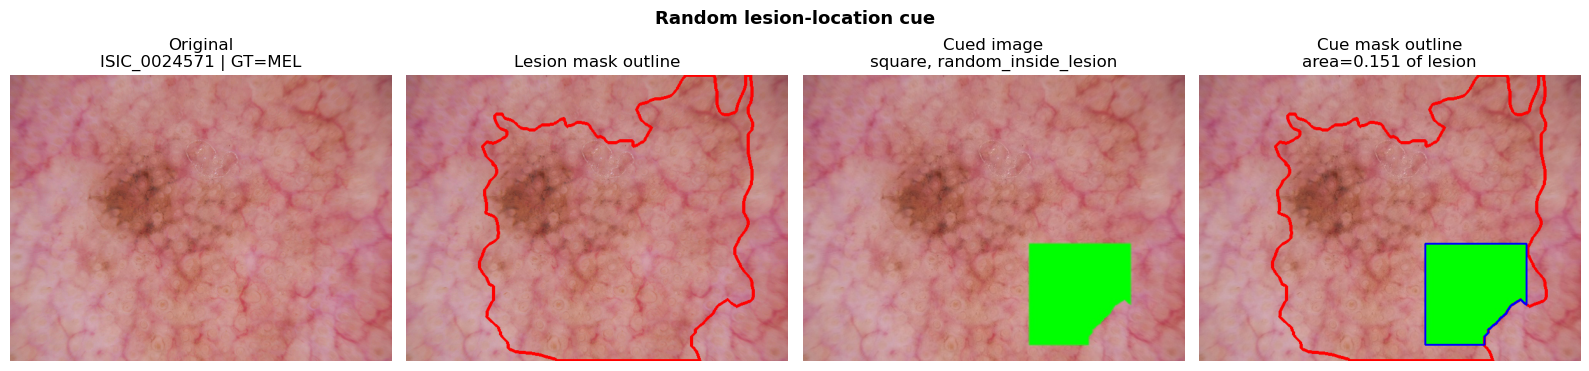

In [7]:
def overlay_contours(rgb: np.ndarray, lesion_mask: np.ndarray | None = None, cue_mask: np.ndarray | None = None) -> np.ndarray:
    out = rgb.copy()
    if lesion_mask is not None:
        contours, _ = cv2.findContours(lesion_mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(out, contours, -1, (255, 0, 0), 3)  # lesion outline red
    if cue_mask is not None:
        contours, _ = cv2.findContours(cue_mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(out, contours, -1, (0, 0, 255), 2)  # cue outline blue
    return out


def plot_cue_example(
    clean_df_source: pd.DataFrame,
    mel_cued_source: pd.DataFrame,
    title_prefix: str,
    image_id: str | None = None,
    sample_idx: int = 0,
):
    if image_id is None:
        row = mel_cued_source.iloc[sample_idx]
    else:
        row = mel_cued_source[mel_cued_source["image_id"] == image_id].iloc[0]

    clean_row = clean_df_source[clean_df_source["image_id"] == row["image_id"]].iloc[0]

    orig_img = load_rgb_image(clean_row)
    cued_img = Image.open(resolve_rel_path(HAM_ROOT, row["image_rel_path"])).convert("RGB")
    lesion_mask = load_lesion_mask(clean_row)
    cue_mask = np.array(Image.open(resolve_rel_path(HAM_ROOT, row["cue_mask_rel_path"])).convert("L")) > 0

    if lesion_mask.shape[:2] != (orig_img.height, orig_img.width):
        lesion_mask = cv2.resize(lesion_mask, (orig_img.width, orig_img.height), interpolation=cv2.INTER_NEAREST)

    if cue_mask.shape[:2] != (orig_img.height, orig_img.width):
        cue_mask = cv2.resize(
            cue_mask.astype(np.uint8),
            (orig_img.width, orig_img.height),
            interpolation=cv2.INTER_NEAREST,
        ).astype(bool)

    orig_arr = np.array(orig_img)
    cued_arr = np.array(cued_img)
    lesion_overlay = overlay_contours(orig_arr, lesion_mask=lesion_mask, cue_mask=None)
    cue_overlay = overlay_contours(cued_arr, lesion_mask=lesion_mask, cue_mask=cue_mask.astype(np.uint8))

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle(title_prefix, fontsize=13, fontweight="bold")

    axes[0].imshow(orig_arr)
    axes[0].set_title(f"Original\n{row['image_id']} | GT={row['gt_label']}")

    axes[1].imshow(lesion_overlay)
    axes[1].set_title("Lesion mask outline")

    axes[2].imshow(cued_arr)
    axes[2].set_title(f"Cued image\n{row.get('cue_shape', '')}, {row.get('cue_placement', '')}")

    axes[3].imshow(cue_overlay)
    axes[3].set_title(
        f"Cue mask outline\narea={row['cue_area_frac_of_lesion']:.3f} of lesion"
    )

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


plot_cue_example(clean_df_fixed, mel_cued_fixed, "Fixed center cue", sample_idx=0)
plot_cue_example(clean_df_fixed, mel_cued_fixed, "Fixed center cue", sample_idx=1)

plot_cue_example(clean_df_random, mel_cued_random, "Random lesion-location cue", sample_idx=0)
plot_cue_example(clean_df_random, mel_cued_random, "Random lesion-location cue", sample_idx=1)

## 7. Optional: plot cue ratio distribution

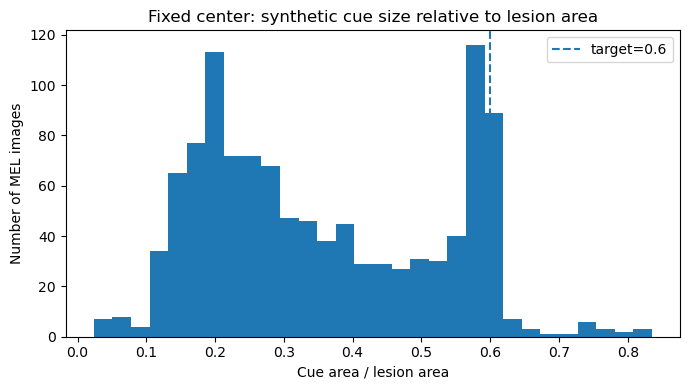

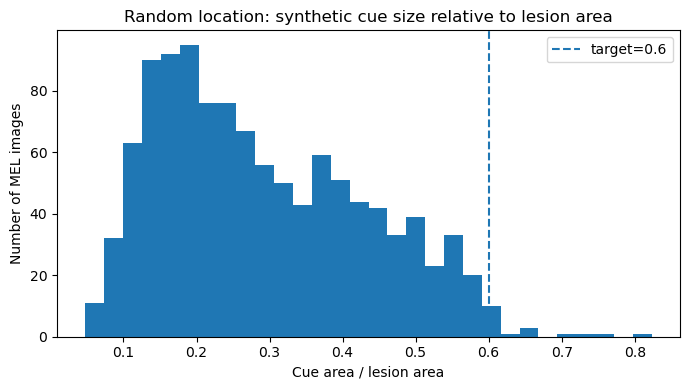

In [8]:
def plot_cue_ratio_hist(mel_cued_source: pd.DataFrame, title: str):
    plt.figure(figsize=(7, 4))
    plt.hist(mel_cued_source["cue_area_frac_of_lesion"].dropna().values, bins=30)
    plt.axvline(TARGET_CUE_AREA_FRAC, linestyle="--", label=f"target={TARGET_CUE_AREA_FRAC}")
    plt.xlabel("Cue area / lesion area")
    plt.ylabel("Number of MEL images")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_cue_ratio_hist(mel_cued_fixed, "Fixed center: synthetic cue size relative to lesion area")
plot_cue_ratio_hist(mel_cued_random, "Random location: synthetic cue size relative to lesion area")

## 8. Save run metadata

In [9]:
def save_metadata(
    syn_root: Path,
    experiment_name: str,
    clean_csv: Path,
    cue_csv: Path,
    image_out_dir: Path,
    cue_mask_out_dir: Path,
    placement: str,
    shape: str,
    color_rgb: tuple[int, int, int],
):
    metadata = {
        "experiment": experiment_name,
        "clean_csv": str(clean_csv.relative_to(REPO_ROOT)),
        "cue_csv": str(cue_csv.relative_to(REPO_ROOT)),
        "image_out_dir": str(image_out_dir.relative_to(REPO_ROOT)),
        "cue_mask_out_dir": str(cue_mask_out_dir.relative_to(REPO_ROOT)),
        "seed": SEED,
        "cue_class": CUE_CLASS,
        "negative_class": NEGATIVE_CLASS,
        "cue_color_rgb": color_rgb,
        "cue_shape": shape,
        "target_cue_area_frac": TARGET_CUE_AREA_FRAC,
        "min_cue_side": MIN_CUE_SIDE,
        "max_cue_side": MAX_CUE_SIDE,
        "placement": placement,
        "class2_to_idx": CLASS2_TO_IDX,
        "notes": [
            "MEL images are modified with a synthetic cue inside the lesion.",
            "NV images are unchanged.",
            "Cue mask is saved for quantitative CAM localization analysis.",
            "Use these CSVs for clean vs cue two-class MEL/NV fine-tuning.",
            "Disable color jitter / CutMix / MixUp in the first controlled run.",
            "Fixed-center and random-location variants are saved separately for traceability.",
        ],
    }

    metadata_path = syn_root / "metadata.json"
    metadata_path.write_text(json.dumps(metadata, indent=2))
    print("Saved metadata:", metadata_path)
    print(json.dumps(metadata, indent=2))


save_metadata(
    syn_root=SYN_ROOT_FIXED,
    experiment_name=FIXED_EXPERIMENT_NAME,
    clean_csv=CLEAN_OUT_CSV_FIXED,
    cue_csv=CUE_OUT_CSV_FIXED,
    image_out_dir=IMAGE_OUT_DIR_FIXED,
    cue_mask_out_dir=CUE_MASK_OUT_DIR_FIXED,
    placement="fixed_center",
    shape=CUE_SHAPE,
    color_rgb=CUE_COLOR_RGB,
)

save_metadata(
    syn_root=SYN_ROOT_RANDOM,
    experiment_name=RANDOM_EXPERIMENT_NAME,
    clean_csv=CLEAN_OUT_CSV_RANDOM,
    cue_csv=CUE_OUT_CSV_RANDOM,
    image_out_dir=IMAGE_OUT_DIR_RANDOM,
    cue_mask_out_dir=CUE_MASK_OUT_DIR_RANDOM,
    placement="random_inside_lesion",
    shape=CUE_SHAPE,
    color_rgb=CUE_COLOR_RGB,
)

Saved metadata: /Users/choekyelnyungmartsang/Developer/master-thesis/data/HAM10000/synthetic_cue/mel_nv_fixed_center_seed42/metadata.json
{
  "experiment": "mel_nv_fixed_center_seed42",
  "clean_csv": "data/HAM10000/synthetic_cue/mel_nv_fixed_center_seed42/csv/ham_mel_nv_clean.csv",
  "cue_csv": "data/HAM10000/synthetic_cue/mel_nv_fixed_center_seed42/csv/ham_mel_nv_cue_on_mel_fixed_center_seed42.csv",
  "image_out_dir": "data/HAM10000/synthetic_cue/mel_nv_fixed_center_seed42/images",
  "cue_mask_out_dir": "data/HAM10000/synthetic_cue/mel_nv_fixed_center_seed42/cue_masks",
  "seed": 42,
  "cue_class": "MEL",
  "negative_class": "NV",
  "cue_color_rgb": [
    0,
    255,
    0
  ],
  "cue_shape": "square",
  "target_cue_area_frac": 0.6,
  "min_cue_side": 80,
  "max_cue_side": 160,
  "placement": "fixed_center",
  "class2_to_idx": {
    "MEL": 0,
    "NV": 1
  },
  "notes": [
    "MEL images are modified with a synthetic cue inside the lesion.",
    "NV images are unchanged.",
    "Cue ma